In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
df = pd.read_csv("student_lifestyle_100k_1.csv", sep = ",")
df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


Смотрим какие признаки у нас есть в таблице и чем они представлены

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  object 
 3   Department          100000 non-null  object 
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), object(2)
memory usage: 7.7+ MB


Смотрим есть ли нулевые значения, чтобы в случае их нахождения заполнить или удалить

In [4]:

df.drop(columns=['Student_ID'], inplace=True)
df = df.rename(columns={"Sleep_Duration": "Sleep",
               "Study_Hours":"Study", "Social_Media_Hours": "Social",
               "Physical_Activity": "Physical", "Stress_Level":"Stress"})
df = df.drop_duplicates()
df['Depression'] = df["Depression"].astype(int)
df.head()

,Age,Gender,Department,CGPA,Sleep,Study,Social,Physical,Stress,Depression
0,22,Female,Science,3.50,7.3,3.3,3.4,114,5,0
1,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,0
2,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,0
3,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,0
4,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,0


Удаляем столбец id, тк оно не несет нужной для нас информации. Также удаляем дубликаты
Переименовываем некоторые столбцы для простоты и краткости при использование далее

In [5]:
df = df[df[['Study', 'Social', 'Sleep']].sum(axis=1) <= 24]
df.head()

,Age,Gender,Department,CGPA,Sleep,Study,Social,Physical,Stress,Depression
0,22,Female,Science,3.50,7.3,3.3,3.4,114,5,0
1,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,0
2,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,0
3,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,0
4,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,0


Удаляем строки, в которых сумма часов сна, учебы, и социальной активноси за день превышает 24 часа, тк это не возможно

In [6]:
print(df['Gender'].value_counts(normalize=True) * 100)
print(df['Depression'].value_counts(normalize=True)*100)

Gender
Male      50.118092
Female    49.881908
Name: proportion, dtype: float64
Depression
0    89.934149
1    10.065851
Name: proportion, dtype: float64


Смотрим соотношение человек по полу. Оно примерно одинаково, что хорошо для нас. Также смотрим соотношение по колличеству студентов с депрессией и без нее. Их количество сильно различается

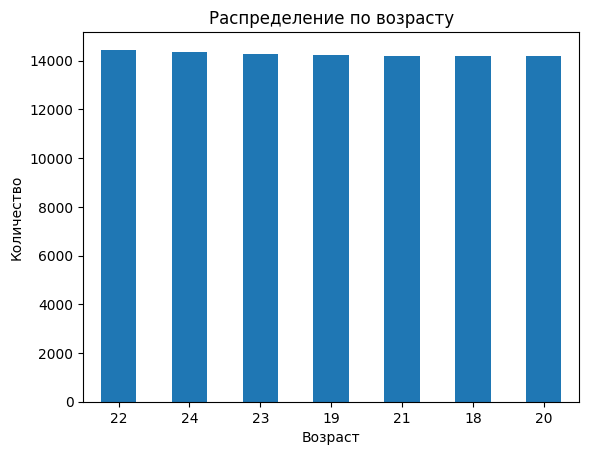

In [7]:
age_count= df['Age'].value_counts()
age_count.plot(kind="bar")
plt.title("Распределение по возрасту")
plt.xlabel("Возраст")
plt.ylabel("Количество")
plt.xticks(rotation=0)
plt.show()

Смотрим распределение людей по возрасту. Оно тоже примерно одинаковое

Gender       Female   Male
Department                
Arts           9998   9984
Business       9931   9965
Engineering    9949  10091
Medical        9872  10076
Science       10093   9963


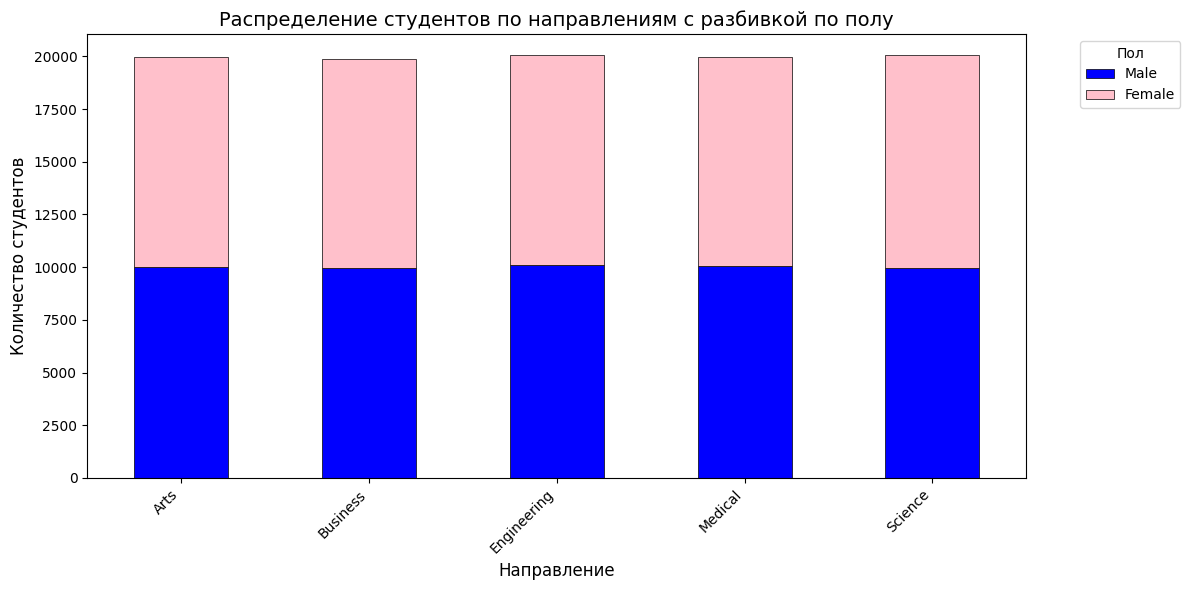

In [8]:
gender_by_major = df.groupby(['Department', 'Gender']).size().unstack(fill_value=0)
colors = {'Male': 'blue', 'Female': 'pink'}
ax = gender_by_major[['Male', 'Female']].plot(
    kind='bar', 
    stacked=True, 
    color=[colors['Male'], colors['Female']],
    figsize=(12, 6),
    edgecolor='black',
    linewidth=0.5
)
print(gender_by_major)
plt.title('Распределение студентов по направлениям с разбивкой по полу', fontsize=14)
plt.xlabel('Направление', fontsize=12)
plt.ylabel('Количество студентов', fontsize=12)
plt.legend(title='Пол', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Смотрим распределение людей по направлению и по полу в каждом направление. Тут тоже количество людей раного пола в каждом направление примерно одинаково

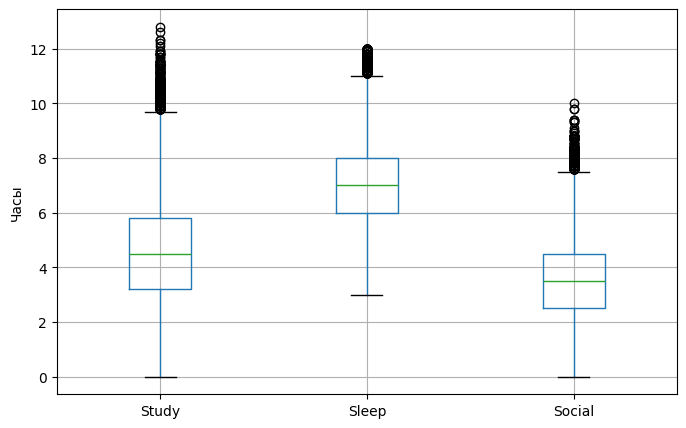

In [9]:
df.boxplot(column=['Study', 'Sleep', 'Social'], figsize=(8,5))
plt.ylabel("Часы")
plt.show()

Ищем выбрасы с помощью ящиков с усами во времени сна, учебы, социальной активности. Видим,что они есть и позже мы их уберем

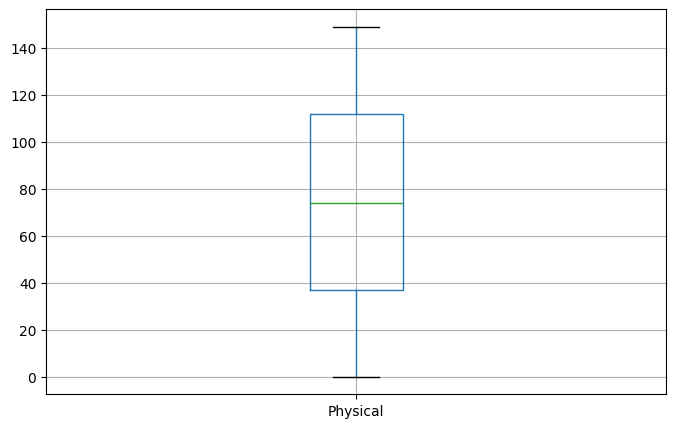

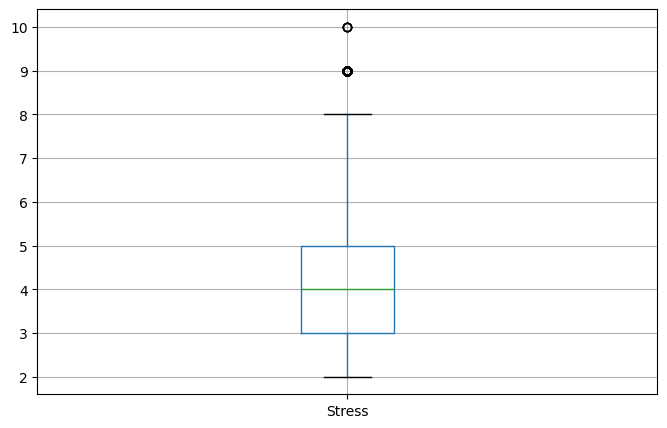

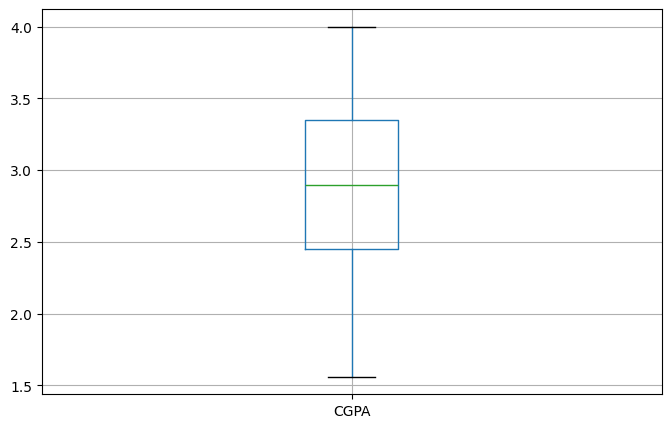

In [10]:
df.boxplot(column=['Physical'], figsize=(8,5))
plt.show()
df.boxplot(column=['Stress'], figsize=(8,5))
plt.show()
df.boxplot(column=['CGPA'], figsize=(8,5))
plt.show()

Также ищем выбросы в оценках, уровне стресса, психологической активности

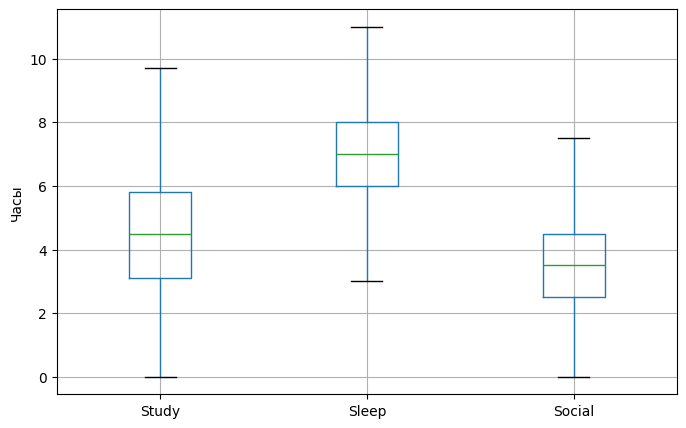

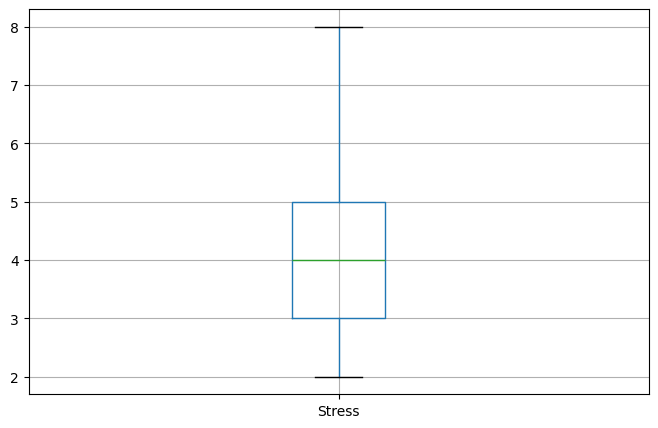

In [11]:
for s in ['Study', 'Social', 'Sleep' ,'Stress']:
    Q1, Q3 = df[s].quantile([0.25, 0.75])
    IQR = Q3 -Q1
    high, low = Q3 + 1.5*IQR, Q1 - 1.5*IQR
    df = df[(df[s]>=low)&(df[s]<=high)]

df.boxplot(column=['Study', 'Sleep', 'Social'], figsize=(8,5))
plt.ylabel("Часы")
plt.show()
df.boxplot(column=['Stress'], figsize=(8,5))
plt.show()

Убираем выбросы и смотрим результат

In [12]:
df['Department'] = df['Department'].map({'Arts': 0, 'Business': 1, 'Engineering':2, 'Medical':3, 'Science': 4})
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
df.head()

,Age,Gender,Department,CGPA,Sleep,Study,Social,Physical,Stress,Depression
0,22,1,4,3.50,7.3,3.3,3.4,114,5,0
1,20,0,2,2.72,5.5,7.2,6.0,142,2,0
2,20,0,3,3.01,5.4,2.3,1.8,137,3,0
3,21,0,2,3.63,8.1,2.0,4.6,130,3,0
4,19,0,0,3.14,6.8,2.6,4.3,4,6,0


Заменяем текстовые данные на числовые

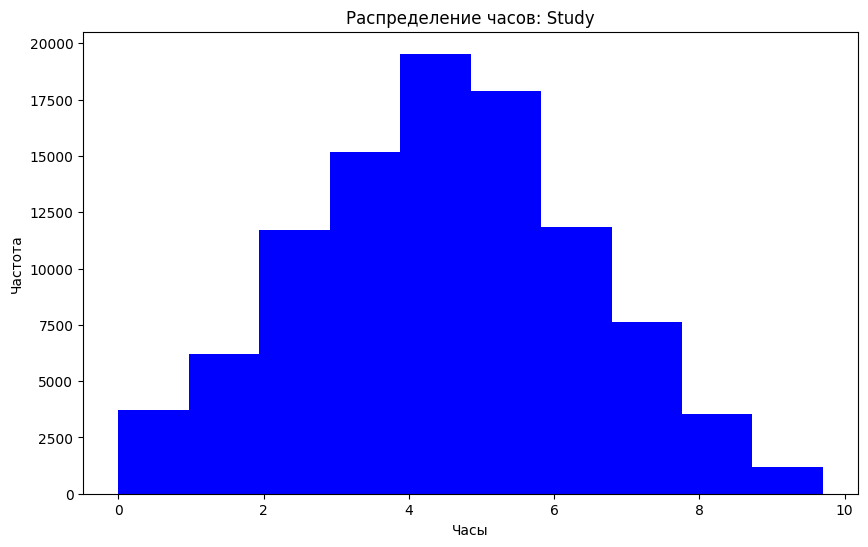

In [13]:
plt.figure(figsize=(10, 6))
plt.hist(df['Study'],color='blue')
plt.xlabel('Часы')
plt.ylabel('Частота')
plt.title('Распределение часов: Study')
plt.show()

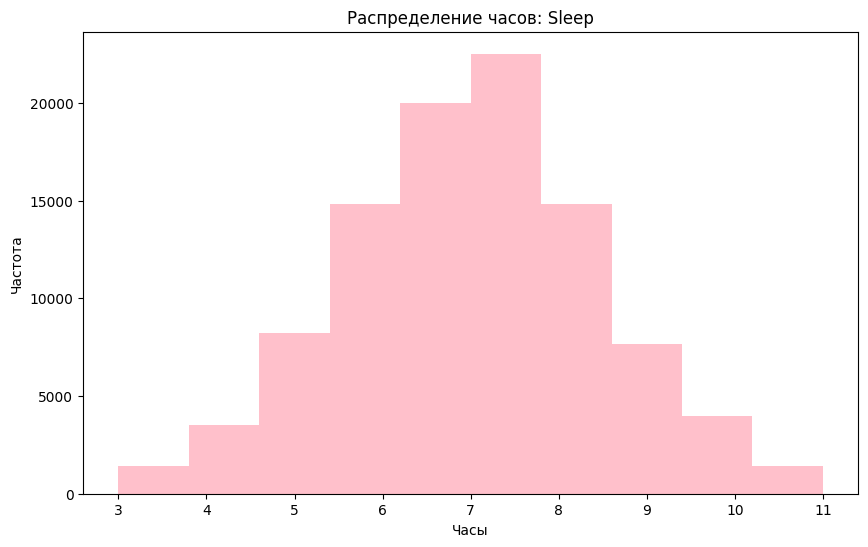

In [14]:
plt.figure(figsize=(10, 6))
plt.hist(df['Sleep'], color='pink')
plt.xlabel('Часы')
plt.ylabel('Частота')
plt.title('Распределение часов: Sleep')
plt.show()

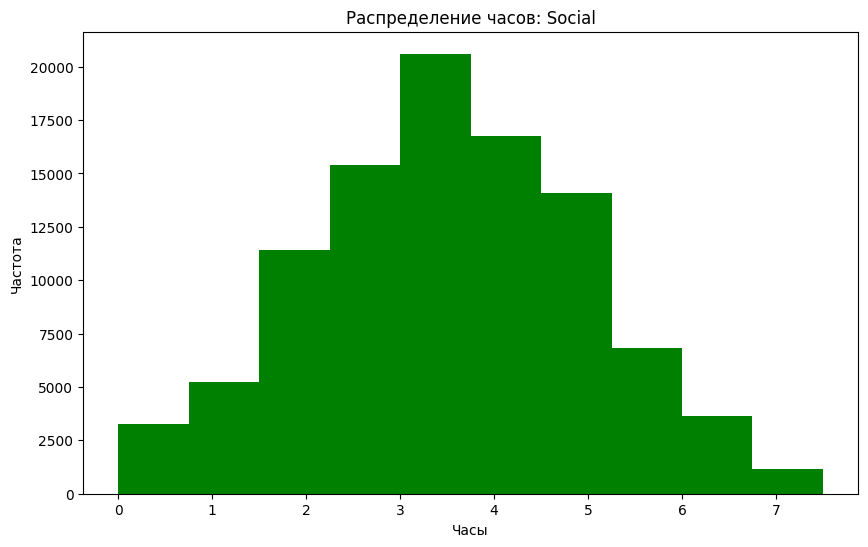

In [15]:
plt.figure(figsize=(10, 6))
plt.hist(df['Social'], color='green')
plt.xlabel('Часы')
plt.ylabel('Частота')
plt.title('Распределение часов: Social')
plt.show()

Нарисуем гистограммы для того чтобы убедиться, что у нас нормальне распределение данных по времени сна, учебы и социальной активности. По гистограммам у нас нормальное распределение данных

In [16]:
#df['Depression_stress'] = df['Depression']*df['Stress']
#df['Study_sleep_ratio'] = df['Study']/df['Sleep']
df['Procrastination'] = df['Social']/(df['Study'] +0.1)
#df['Study_sq'] = df['Study'] ** 2
#df['Health'] = (df['Sleep'] * df['Physical']) / (df['Stress'] + 1)
df.head()

,Age,Gender,Department,CGPA,Sleep,Study,Social,Physical,Stress,Depression,Procrastination
0,22,1,4,3.50,7.3,3.3,3.4,114,5,0,1.000000
1,20,0,2,2.72,5.5,7.2,6.0,142,2,0,0.821918
2,20,0,3,3.01,5.4,2.3,1.8,137,3,0,0.750000
3,21,0,2,3.63,8.1,2.0,4.6,130,3,0,2.190476
4,19,0,0,3.14,6.8,2.6,4.3,4,6,0,1.592593


Подбирае какой новый признак на основе, имеющихся данных, можно добавит в дата сет

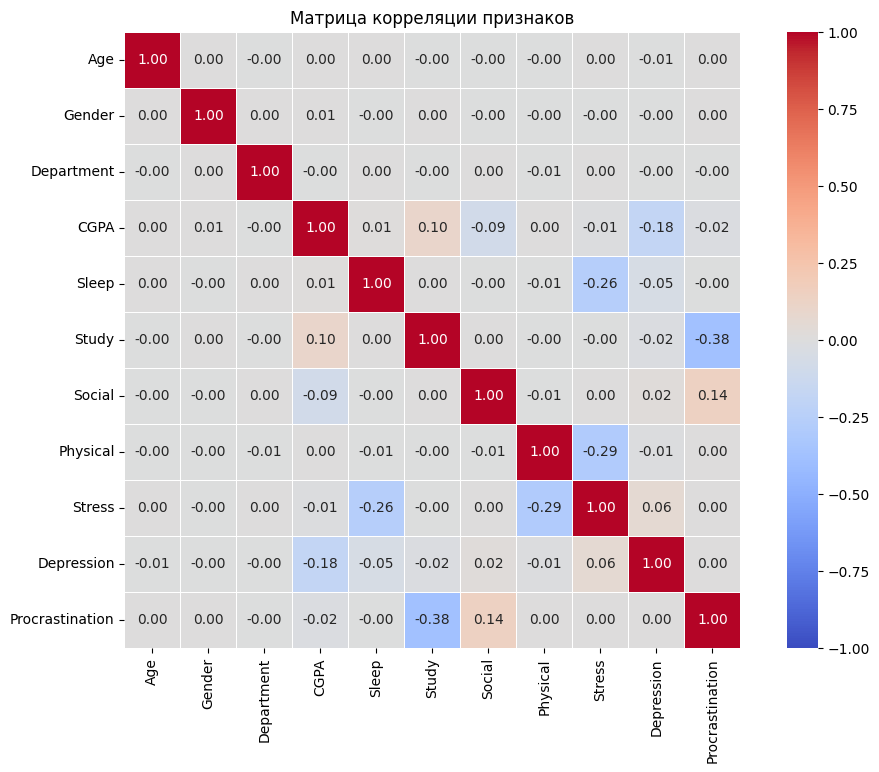

In [17]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(),
            vmin= -1,
            vmax = 1, 
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            square=True,
            linewidths=0.5)
plt.title('Матрица корреляции признаков')
plt.show()

Выведем таблицу для проверки корреляции признаков. По таблице мы видим, что у нас нет сильной коррелции признаков

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

y = df['CGPA']
X = df.drop(columns=['CGPA'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

def evaluate_model(y_true, y_pred, dataset_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    print(f"\nМетрики для {dataset_name}:")
    print(f"  MAE:  {mae:,.2f}")
    print(f"  RMSE: {rmse:,.2f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")

    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

train_metrics = evaluate_model(y_train, y_train_pred, "Train")
test_metrics = evaluate_model(y_test, y_test_pred, "Test")

r2_diff = train_metrics['R2'] - test_metrics['R2']
print(f"\nДиагностика:")
print(f"  Разница R² (Train - Test): {r2_diff:.4f}")
if r2_diff > 0.1:
    print("Возможное переобучение! Рассмотрите регуляризацию (Ridge/Lasso).")
elif r2_diff < -0.1:
    print("Необычная ситуация: тест лучше трейна. Проверьте разделение данных.")
else:
    print("Модель обобщает данные адекватно.")


Метрики для Train:
  MAE:  0.44
  RMSE: 0.52
  R²:   0.0490
  MAPE: 16.15%

Метрики для Test:
  MAE:  0.44
  RMSE: 0.52
  R²:   0.0499
  MAPE: 15.98%

Диагностика:
  Разница R² (Train - Test): -0.0009
Модель обобщает данные адекватно.


Обучаем модель с линейной регрессией для вычисления среднего балла студента на основе всех остальных данных. Пометрика видно, что модель допескает ошибки, но предсказанные значение не имеют сильных отклонений от реальных, тк MAE и RMAE примерно одинаковы. Но R^2 почти равна нулю это сзначит что модель предсказывает не лучше, чем среднее, поэтому в нашей ситуации модель относительно бесполезна. Скорее всего такое присходит из-за того, что у признака CGPA нет сильной корреляци не с одним другим признаком, отсюда и следует бесполеззность линейной модели

In [19]:
y = df['CGPA']
X = df.drop(columns=['CGPA', 'Social', 'Age', 'Gender', 'Department', 'Physical', 'Stress', 'Depression'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

train_metrics = evaluate_model(y_train, y_train_pred, "Train")
test_metrics = evaluate_model(y_test, y_test_pred, "Test")

r2_diff = train_metrics['R2'] - test_metrics['R2']
print(f"\nДиагностика:")
print(f"  Разница R² (Train - Test): {r2_diff:.4f}")
if r2_diff > 0.1:
    print("Возможное переобучение! Рассмотрите регуляризацию (Ridge/Lasso).")
elif r2_diff < -0.1:
    print("Необычная ситуация: тест лучше трейна. Проверьте разделение данных.")
else:
    print("Модель обобщает данные адекватно.")


Метрики для Train:
  MAE:  0.46
  RMSE: 0.53
  R²:   0.0098
  MAPE: 16.62%

Метрики для Test:
  MAE:  0.45
  RMSE: 0.53
  R²:   0.0084
  MAPE: 16.47%

Диагностика:
  Разница R² (Train - Test): 0.0014
Модель обобщает данные адекватно.


Здесь в паремтрах для обучения я взяла только, те признаки, что требовались в ТЗ, но результат линеной модели только ухудшился. Это происходит также из-за того, что у CGPA нет корреляции другими признаками.

In [20]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_classification(y_true, y_pred, y_proba=None, dataset_name = "Dataset_name"):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc_roc = roc_auc_score(y_true, y_proba) if y_proba is not None else None

    print(f"\n Метрики для {dataset_name}")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    if auc_roc:
        print(f"  AUC-ROC:   {auc_roc:.4f}")

    return {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1': f1, 'AUC-ROC': auc_roc}

y = df['Depression']
X = df.drop(columns=['Depression'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

best_n_epochs = 0
best_learning_rate = 0
max_recall = 0
max_precision = 0
for n_epochs in range(50, 1001, 50):
    for learning_rate in [0.5, 0.1, 0.01, 0.001, 0.0001]:
        model = SGDClassifier(
            penalty='l1',
            tol=None,
            alpha=0.001,
            loss='log_loss',
            max_iter=n_epochs,
            eta0=learning_rate,
            learning_rate='constant',
            class_weight='balanced',
            random_state=42
        )
        model.fit(X_train_scaled, y_train)

        y_train_pred = model.predict(X_train_scaled)
        if precision_score(y_train, y_train_pred, zero_division=0) > max_precision:
            max_precision = precision_score(y_train, y_train_pred, zero_division=0)
            
print(max_precision) #0.21

0.2132984684348151


Здесь я смотрю максимальное возможный percision путем перебора эпох и шага, для того чтобы позже найти оптимальное сочетание percision и recall. В этом случае я беру все признаки для обучения, кроме депресии.

In [21]:
for n_epochs in range(50, 1001, 50):
    for learning_rate in [0.5, 0.1, 0.01, 0.001, 0.0001]:
        model = SGDClassifier(
            penalty='l1',
            tol=None,
            alpha=0.001,
            loss='log_loss',
            max_iter=n_epochs,
            eta0=learning_rate,
            learning_rate='constant',
            class_weight='balanced',
            random_state=42
        )
        model.fit(X_train_scaled, y_train)

        y_train_pred = model.predict(X_train_scaled)
        if max_recall < recall_score(y_train, y_train_pred, zero_division=0) and precision_score(y_train, y_train_pred, zero_division=0) >= 0.16:
            max_recall = recall_score(y_train, y_train_pred, zero_division=0)
            best_n_epochs = n_epochs
            best_learning_rate = learning_rate

model = SGDClassifier(
    penalty='l1',
    verbose= 1,
    tol=None,
    alpha=0.001,
    loss='log_loss',
    max_iter=best_n_epochs,
    eta0=best_learning_rate,
    learning_rate='constant',
    class_weight='balanced',
    random_state=42
)
model.fit(X_train_scaled, y_train)

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
y_test_proba = model.predict_proba(X_test_scaled)[:, 1]

train_metrics = evaluate_classification(y_train, y_train_pred, dataset_name ="Train")
test_metrics = evaluate_classification(y_test, y_test_pred, y_proba=y_test_proba, dataset_name ="Test")

print(f"\nДиагностика Логистической Регрессии:")
print(f"  Количество эпох: {best_n_epochs}") #550
print(f"  Learning Rate: {best_learning_rate}") #0.001

acc_diff = train_metrics['Accuracy'] - test_metrics['Accuracy']
if acc_diff > 0.1:
    print("\nВозможное переобучение! Разница Accuracy > 10%")
    print("   Попробуйте увеличить alpha (регуляризацию)")
elif acc_diff < -0.05:
    print("\n Необычная ситуация: тест лучше трейна. Проверьте разделение данных.")
else:
    print("\n Модель обобщает данные адекватно.")

-- Epoch 1
Norm: 0.90, NNZs: 8, Bias: -0.236810, T: 78705, Avg. loss: 0.648754
Total training time: 0.01 seconds.
-- Epoch 2
Norm: 0.99, NNZs: 5, Bias: -0.185230, T: 157410, Avg. loss: 0.641063
Total training time: 0.02 seconds.
-- Epoch 3
Norm: 1.18, NNZs: 5, Bias: -0.156075, T: 236115, Avg. loss: 0.641889
Total training time: 0.04 seconds.
-- Epoch 4
Norm: 1.37, NNZs: 5, Bias: -0.189835, T: 314820, Avg. loss: 0.642965
Total training time: 0.05 seconds.
-- Epoch 5
Norm: 1.51, NNZs: 5, Bias: -0.163569, T: 393525, Avg. loss: 0.641651
Total training time: 0.06 seconds.
-- Epoch 6
Norm: 1.63, NNZs: 5, Bias: -0.192756, T: 472230, Avg. loss: 0.642726
Total training time: 0.06 seconds.
-- Epoch 7
Norm: 1.75, NNZs: 4, Bias: -0.146859, T: 550935, Avg. loss: 0.641138
Total training time: 0.07 seconds.
-- Epoch 8
Norm: 1.85, NNZs: 4, Bias: -0.233234, T: 629640, Avg. loss: 0.643692
Total training time: 0.08 seconds.
-- Epoch 9
Norm: 1.96, NNZs: 5, Bias: -0.184839, T: 708345, Avg. loss: 0.640872
T

Здесь уже зная максимальный persicion, я его немного понижаю и оптимальное сочетание recall и percision также перебором, только в конце добавление условие и на recall и percision. После найдя нужное количество эпох и шаг, при которых метрики оптимальный. Я обучаю модель и вывожу все метрики для тренеровочной выборки и тестовой, сводку об обучение на каждой эпохе, а также проверяю модель на переобучение путем подсчета разницы accuracy  в тестовой и тренеровочный выборки. По метрикам мы видим, что модель находит довольно большое количество студентов с депрессие, но ее результаты часто являються ложноположительными. В ситуации если бы мы использовали, ее для реального поиска студентов с депрессие это не было бы очень плохо.

In [ ]:
y = df['Depression']
X = df.drop(columns=['CGPA', 'Age', 'Gender', 'Department', 'Stress', 'Depression'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

best_n_epochs = 0
best_learning_rate = 0
max_recall = 0
max_precision = 0
for n_epochs in range(50, 1001, 50):
    for learning_rate in [0.5, 0.1, 0.01, 0.001, 0.0001]:
        model = SGDClassifier(
            penalty='l1',
            tol=None,
            alpha=0.001,
            loss='log_loss',
            max_iter=n_epochs,
            eta0=learning_rate,
            learning_rate='constant',
            class_weight='balanced',
            random_state=42
        )
        model.fit(X_train_scaled, y_train)

        y_train_pred = model.predict(X_train_scaled)
        if precision_score(y_train, y_train_pred, zero_division=0) > max_precision:
            max_precision = precision_score(y_train, y_train_pred, zero_division=0)
            
print(max_precision)# 0.2

Здесь я повтряю все предыдущие действия с поиском percision, но только для используя не все признаки, а те что указаны в ТЗ.

In [ ]:
for n_epochs in range(50, 1001, 50):
    for learning_rate in [0.5, 0.1, 0.01, 0.001, 0.0001]:
        model = SGDClassifier(
            penalty='l1',
            tol=None,
            alpha=0.001,
            loss='log_loss',
            max_iter=n_epochs,
            eta0=learning_rate,
            learning_rate='constant',
            class_weight='balanced',
            random_state=42
        )
        model.fit(X_train_scaled, y_train)

        y_train_pred = model.predict(X_train_scaled)
        if precision_score(y_train, y_train_pred, zero_division=0) > 0.11 and recall_score(y_train, y_train_pred, zero_division=0) > max_recall:
            max_recall = recall_score(y_train, y_train_pred, zero_division=0)
            best_n_epochs = n_epochs
            best_learning_rate = learning_rate

model = SGDClassifier(
    penalty='l1',
    verbose= 1,
    tol=None,
    alpha=0.001,
    loss='log_loss',
    max_iter=best_n_epochs,
    eta0=best_learning_rate,
    learning_rate='constant',
    class_weight='balanced',
    random_state=42
)
model.fit(X_train_scaled, y_train)

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
y_test_proba = model.predict_proba(X_test_scaled)[:, 1]

train_metrics = evaluate_classification(y_train, y_train_pred, dataset_name ="Train")
test_metrics = evaluate_classification(y_test, y_test_pred, y_proba=y_test_proba, dataset_name ="Test")

print(f"\nДиагностика Логистической Регрессии:")
print(f"  Количество эпох: {best_n_epochs}")
print(f"  Learning Rate: {best_learning_rate}")

acc_diff = train_metrics['Accuracy'] - test_metrics['Accuracy']
if acc_diff > 0.1:
    print("\nВозможное переобучение! Разница Accuracy > 10%")
    print("   Попробуйте увеличить alpha (регуляризацию)")
elif acc_diff < -0.05:
    print("\n Необычная ситуация: тест лучше трейна. Проверьте разделение данных.")
else:
    print("\n Модель обобщает данные адекватно.")

NameError: name 'SGDClassifier' is not defined

Здесь также повторяется поиск оптимального recall и persicion, но только для выборки с признаками указаными в ТЗ. В конце также выводятся все метрики и проверяется модель на переобучение, для оптимальных найденных количества эпох и шага. По метрикам мы опять же видим, что модель как и в предыдущем случае не переобучается, работает лучше,чем просто взятие среднего, но часто ошибается выдавая ложноположительные результаты, но находя студентов с депрессие. Также она выводит проиежуточные этапы обучения для каждой эпохи.

Итог
1) В предобработки данный мы выяснили, что соотношее данных в датасете довольно равномерное. Исключением является количество людей с депрессией и без из-за чего далее при обучение модели логорифмической регрессии нап пришлось импользовать class_weight='balanced', чтобы модель обучалась адекватно. Также для адекватного обучения модели мы удалили выбросы (наши типы моделий довольно чувчтыительны к выбросам, и они могут сильно ухудшить веса и увеличить количество ошибок). Также я смотрела корреляцию, чтобы понять какие признаки сильно зависят друг от друга, тогда их можно было бы удалить (таких признаков не нашлось, корреляция везде ближе к нулю). Еще я добавила навый признак прокрастинация, котторый основан на уже имеющихся, для более лучшего обучения моделей.
2) Далее я обучаю модель линейной регресии (я делаю две, что бы посмотреть какие результаты будут, если использовать все имеющиеся признаки и признаки из ТЗ). В обоих случаях мы по метрикам мы видим, что модель работает довольно плохо (предсказывате результат не лучше. если брать среднее), тк у нас у всех признаков низкая корреляция, а значит между ними нельзя построить линейнюу зависимость.
3) Далее обучаем модель логарифмическойй регрессии (также две, чтобы посмотреть результат при всех признаках и указаных в ТЗ). Сначала перебором выясняем максимально вохможный persicion, потом берем его чуть меньше и ищем оптимальное социтание percision и recall (все это ищем только на тренировочной выборке). Когда мы нашли оптимальной сочетание мы запомнили нужное количество эпох и шаг. Обучаем модель с нужным количеством эпох и шагов, выводим метрики для тестовой и тренировочной выборки, проверяем модель на перобучение и делаем вывод. Вывод для обеих моделий одиноковый они находят не плохое количество депрессивных студентов, но результат часто ложноположительный.
4) Такие результаты скорее всего поисходят из-за того, что датасет сгенирирован, а также для определения депресии нужны еще какиенибуть признаки, а не только данные нам
P.S Я знаю, что мой вариант подбора работает долго. Изнасально я пыталась все это сделать руками. Руками я также подобрала alpha и penalty. Но после многочисленный попыток подобрать шаг и эпохи руками из-за того, что каждый раз у меня получалось довольно низкий recall и percision, а также loss изначальный не сильно отлисался от конечного, я начала сомневаться в том, что подобранный мною случаи оптимальны. Поэтому я решила попробовать сделать перебором (руками делать было бы еще дольше и слишком много надо было бы отразить в коде, чтобы показать процесс подбора), чтобы точно убедиться, что в подобранных мною случаях соотношение метрик оптимально. (В среднем каждый перебор работает по 20 мин (все признаки), по 12 мин (признаки из ТЗ), поэтому подобранные эпохи и шаг я записала в комментариях) 